In [1]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


### Data Splitting

In [2]:
import os
import shutil
import random
from PIL import Image
import tensorflow as tf

# 1. Download a reliable, open mirror of the dataset
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_abaeed85be34aaf5a8fc104267c0a781'
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset
!unzip -q kaggle-cat-vs-dog-dataset.zip

# 2. Setup the directory structure
base_dir = 'dataset_v2'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir): shutil.rmtree(base_dir)

for split in [train_dir, test_dir]:
    for category in ['cats', 'dogs']:
        os.makedirs(os.path.join(split, category), exist_ok=True)

# 3. Reorganize from 'kagglecatsanddogs_3367a/PetImages'
# This mirror typically extracts into a folder called 'kagglecatsanddogs_3367a'
src_root = 'kagglecatsanddogs_3367a/PetImages'

def process_split(animal_type, source_folder, train_target, test_target, split_ratio=0.8):
    files = [f for f in os.listdir(os.path.join(src_root, source_folder)) if f.endswith('.jpg')]
    random.shuffle(files)

    split_idx = int(len(files) * split_ratio)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    for f in train_files:
        shutil.copy(os.path.join(src_root, source_folder, f), os.path.join(train_target, f))
    for f in test_files:
        shutil.copy(os.path.join(src_root, source_folder, f), os.path.join(test_target, f))

print("Organizing dataset into v2 structure...")
process_split('cats', 'Cat', os.path.join(train_dir, 'cats'), os.path.join(test_dir, 'cats'))
process_split('dogs', 'Dog', os.path.join(train_dir, 'dogs'), os.path.join(test_dir, 'dogs'))

print(f"Dataset ready at: {os.path.abspath(base_dir)}")

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
100% 787M/787M [00:09<00:00, 83.8MB/s]

Organizing dataset into v2 structure...
Dataset ready at: /content/dataset_v2


In [3]:
import os

def count_files(directory):
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

train_cats = count_files('dataset_v2/train/cats')
train_dogs = count_files('dataset_v2/train/dogs')
test_cats = count_files('dataset_v2/test/cats')
test_dogs = count_files('dataset_v2/test/dogs')

print(f"Total Training Images: {train_cats + train_dogs} ({train_cats} cats, {train_dogs} dogs)")
print(f"Total Testing Images: {test_cats + test_dogs} ({test_cats} cats, {test_dogs} dogs)")

Total Training Images: 19967 (9992 cats, 9975 dogs)
Total Testing Images: 4992 (2498 cats, 2494 dogs)


### Imports

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D,Flatten, BatchNormalization, Dropout

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    directory="/content/dataset_v2/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory="/content/dataset_v2/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)

Found 19967 files belonging to 2 classes.
Found 4992 files belonging to 2 classes.


In [6]:
#Normalize
def process(image, label):
  image = tf.cast(image/255. ,tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

### Create CNN model

In [7]:
# Create CNN model
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation=tf.keras.layers.LeakyReLU(alpha=0.1),input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation=tf.keras.layers.LeakyReLU(alpha=0.1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation=tf.keras.layers.LeakyReLU(alpha=0.1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation=tf.keras.layers.LeakyReLU(alpha=0.1)))
model.add(Dropout(0.1))
model.add(Dense(64,activation=tf.keras.layers.LeakyReLU(alpha=0.1)))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
import PIL
from PIL import Image
import os

def clean_and_convert_images(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg')):
                path = os.path.join(root, file)
                try:
                    with Image.open(path) as img:
                        if img.mode != 'RGB':
                            rgb_img = img.convert('RGB')
                            rgb_img.save(path)
                        img.verify()
                except Exception as e:
                    if os.path.exists(path): os.remove(path)

print("Cleaning dataset...")
clean_and_convert_images("/content/dataset_v2/train")
clean_and_convert_images("/content/dataset_v2/test")

# Re-load datasets
train_ds = keras.utils.image_dataset_from_directory(
    "/content/dataset_v2/train",
    label_mode="int",
    image_size=(256, 256),
    batch_size=32
).map(process)

validation_ds = keras.utils.image_dataset_from_directory(
    "/content/dataset_v2/test",
    label_mode="int",
    image_size=(256, 256),
    batch_size=32
).map(process)

# Use ignore_errors() to skip any batches that trigger decoding issues during execution
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
validation_ds = validation_ds.apply(tf.data.experimental.ignore_errors())

print("Starting training with error-handling pipeline...")
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Cleaning dataset...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Found 19916 files belonging to 2 classes.
Found 4982 files belonging to 2 classes.


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Starting training with error-handling pipeline...
Epoch 1/10
    620/Unknown 69s 90ms/step - accuracy: 0.5848 - loss: 2.7934

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


620/620 ━━━━━━━━━━━━━━━━━━━━ 78s 105ms/step - accuracy: 0.6132 - loss: 1.4737 - val_accuracy: 0.6911 - val_loss: 0.7089
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.6928 - loss: 0.6246 - val_accuracy: 0.7280 - val_loss: 0.5964
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.7474 - loss: 0.5385 - val_accuracy: 0.7618 - val_loss: 0.5074
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7826 - loss: 0.4703 - val_accuracy: 0.7851 - val_loss: 0.4666
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8184 - loss: 0.4110 - val_accuracy: 0.7728 - val_loss: 0.5147
Epoch 6/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8471 - loss: 0.3578 - val_accuracy: 0.7992 - val_loss: 0.4602
Epoch 7/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 90s 145ms/step - accuracy: 0.8740 - loss: 0.2923 - val_accuracy: 0.7996 - val_loss: 1.4573
Epoch 8/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9052 - loss: 0.2264 - val_accu

### Graph plots


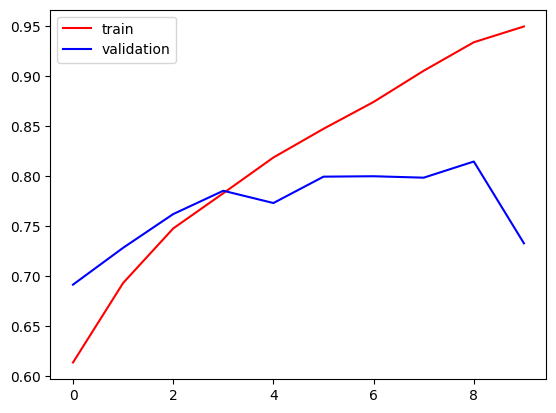

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

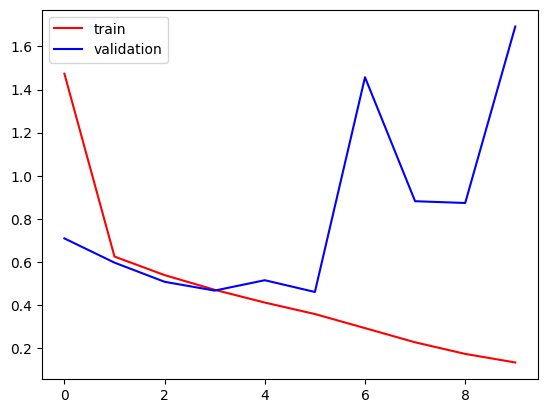

In [12]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [14]:
from google.colab import files

# Save the model first
model.save("dog_cat_classifier_cnn_model.keras")

files.download("dog_cat_classifier_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>